In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("dataset_analisis.csv")

df.head()

,id,fecha,vendedor,region,categoria,producto,cantidad,precio_unitario,descuento,cliente,edad_cliente,genero
0,1,2024-01-03,Ana Garcia,Norte,Electronica,Laptop,2.0,35000.0,0.05,Juan Perez,34,M
1,2,2024-01-05,Carlos Lopez,Sur,Ropa,Camiseta,15.0,850.0,0.00,Maria Santos,28,F
2,3,2024-01-07,Maria Perez,Este,Alimentacion,Arroz 5lb,30.0,250.0,0.10,Pedro Gomez,45,M
3,4,2024-01-08,Ana Garcia,Norte,Electronica,Audifonos,8.0,1200.0,0.05,Laura Diaz,31,F
4,5,2024-01-10,Luis Soto,Oeste,Ropa,Pantalon,10.0,1500.0,0.00,Carlos Ruiz,52,M


In [10]:
# Revisamos el tamaño del dataset
print("Filas y columnas:", df.shape)

# Revisamos los nombres de las columnas
print("\nColumnas:")
print(df.columns.tolist())

# Revisamos los tipos de datos
print("\nInformación del dataset:")
df.info()

Filas y columnas: (77, 12)

Columnas:
['id', 'fecha', 'vendedor', 'region', 'categoria', 'producto', 'cantidad', 'precio_unitario', 'descuento', 'cliente', 'edad_cliente', 'genero']

Información del dataset:
<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               77 non-null     int64  
 1   fecha            77 non-null     str    
 2   vendedor         77 non-null     str    
 3   region           77 non-null     str    
 4   categoria        77 non-null     str    
 5   producto         77 non-null     str    
 6   cantidad         77 non-null     float64
 7   precio_unitario  77 non-null     float64
 8   descuento        76 non-null     str    
 9   cliente          77 non-null     str    
 10  edad_cliente     77 non-null     str    
 11  genero           74 non-null     str    
dtypes: float64(2), int64(1), str(9)
memory usage: 7.3 K

In [11]:
# Revisamos cuántos valores nulos hay en cada columna
print(df.isnull().sum())


id                 0
fecha              0
vendedor           0
region             0
categoria          0
producto           0
cantidad           0
precio_unitario    0
descuento          1
cliente            0
edad_cliente       0
genero             3
dtype: int64


In [12]:
# Revisamos si existen IDs duplicados
print("IDs duplicados:", df["id"].duplicated().sum())

# Mostramos los registros que tienen ID duplicado
df[df["id"].duplicated(keep=False)]

IDs duplicados: 2


,id,fecha,vendedor,region,categoria,producto,cantidad,precio_unitario,descuento,cliente,edad_cliente,genero
2,3,2024-01-07,Maria Perez,Este,Alimentacion,Arroz 5lb,30.0,250.0,0.10,Pedro Gomez,45,M
9,10,2024-01-19,Carlos Lopez,Sur,Electronica,Teclado,6.0,1800.0,0.05,Sofia Reyes,33,F
75,3,2024-01-07,Maria Perez,Este,Alimentacion,Arroz 5lb,30.0,250.0,0.10,Pedro Gomez,45,M
76,10,2024-01-19,Carlos Lopez,Sur,Electronica,Teclado,6.0,1800.0,0.05,Sofia Reyes,33,F


In [13]:
# Revisamos cuántos valores nulos hay en cada columna
print(df.isnull().sum())

id                 0
fecha              0
vendedor           0
region             0
categoria          0
producto           0
cantidad           0
precio_unitario    0
descuento          1
cliente            0
edad_cliente       0
genero             3
dtype: int64


In [14]:
# Revisamos si existen IDs duplicados
print("IDs duplicados:", df["id"].duplicated().sum())

# Mostramos los registros que tienen ID duplicado
df[df["id"].duplicated(keep=False)]

IDs duplicados: 2


,id,fecha,vendedor,region,categoria,producto,cantidad,precio_unitario,descuento,cliente,edad_cliente,genero
2,3,2024-01-07,Maria Perez,Este,Alimentacion,Arroz 5lb,30.0,250.0,0.10,Pedro Gomez,45,M
9,10,2024-01-19,Carlos Lopez,Sur,Electronica,Teclado,6.0,1800.0,0.05,Sofia Reyes,33,F
75,3,2024-01-07,Maria Perez,Este,Alimentacion,Arroz 5lb,30.0,250.0,0.10,Pedro Gomez,45,M
76,10,2024-01-19,Carlos Lopez,Sur,Electronica,Teclado,6.0,1800.0,0.05,Sofia Reyes,33,F


In [15]:
# Corregir valores nulos
df["descuento"] = df["descuento"].fillna(0)
df["genero"] = df["genero"].fillna("No especificado")

In [16]:
# Eliminar duplicados usando id como clave única
df = df.drop_duplicates(subset="id", keep="first")

In [17]:
print(df.isnull().sum())
print("IDs duplicados:", df["id"].duplicated().sum())

id                 0
fecha              0
vendedor           0
region             0
categoria          0
producto           0
cantidad           0
precio_unitario    0
descuento          0
cliente            0
edad_cliente       0
genero             0
dtype: int64
IDs duplicados: 0


In [18]:
# CONVERTIR TIPOS DE DATOS

# Convertir la fecha al tipo datetime
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# Convertir columnas numéricas
df["cantidad"] = pd.to_numeric(df["cantidad"], errors="coerce")
df["precio_unitario"] = pd.to_numeric(df["precio_unitario"], errors="coerce")
df["descuento"] = pd.to_numeric(df["descuento"], errors="coerce")
df["edad_cliente"] = pd.to_numeric(df["edad_cliente"], errors="coerce")

# Verificar los tipos de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 75 entries, 0 to 74
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               75 non-null     int64         
 1   fecha            74 non-null     datetime64[us]
 2   vendedor         75 non-null     str           
 3   region           75 non-null     str           
 4   categoria        75 non-null     str           
 5   producto         75 non-null     str           
 6   cantidad         75 non-null     float64       
 7   precio_unitario  75 non-null     float64       
 8   descuento        72 non-null     float64       
 9   cliente          75 non-null     str           
 10  edad_cliente     72 non-null     float64       
 11  genero           75 non-null     str           
dtypes: datetime64[us](1), float64(4), int64(1), str(6)
memory usage: 7.2 KB


In [19]:
print(df.isnull().sum())

id                 0
fecha              1
vendedor           0
region             0
categoria          0
producto           0
cantidad           0
precio_unitario    0
descuento          3
cliente            0
edad_cliente       3
genero             0
dtype: int64


In [20]:
df[df["id"].isin([46, 47, 48])]

,id,fecha,vendedor,region,categoria,producto,cantidad,precio_unitario,descuento,cliente,edad_cliente,genero
45,46,NaT,Norte,Electronica,Mouse,5,650.0,0.00,NaN,30,NaN,No especificado
46,47,2024-04-02,Carlos Lopez,Ropa,Camiseta,8,850.0,0.10,NaN,22,NaN,No especificado
47,48,2024-04-04,Maria Perez,Este,Laptop,2,35000.0,0.05,NaN,37,NaN,No especificado


In [21]:
# CORREGIR FILAS DESPLAZADAS DEL ARCHIVO ORIGINAL

# ID 46
df.loc[df["id"] == 46, "fecha"] = "2024-04-01"
df.loc[df["id"] == 46, "vendedor"] = "Ana Garcia"
df.loc[df["id"] == 46, "region"] = "Norte"
df.loc[df["id"] == 46, "categoria"] = "Electronica"
df.loc[df["id"] == 46, "producto"] = "Mouse"
df.loc[df["id"] == 46, "cantidad"] = 5
df.loc[df["id"] == 46, "precio_unitario"] = 650
df.loc[df["id"] == 46, "descuento"] = 0
df.loc[df["id"] == 46, "cliente"] = "Carmen Lopez"
df.loc[df["id"] == 46, "edad_cliente"] = 30
df.loc[df["id"] == 46, "genero"] = "F"

# ID 47
df.loc[df["id"] == 47, "region"] = "Sur"
df.loc[df["id"] == 47, "categoria"] = "Ropa"
df.loc[df["id"] == 47, "producto"] = "Camiseta"
df.loc[df["id"] == 47, "cantidad"] = 8
df.loc[df["id"] == 47, "precio_unitario"] = 850
df.loc[df["id"] == 47, "descuento"] = 0.10
df.loc[df["id"] == 47, "cliente"] = "Luis Gonzalez"
df.loc[df["id"] == 47, "edad_cliente"] = 22
df.loc[df["id"] == 47, "genero"] = "M"

# ID 48
df.loc[df["id"] == 48, "categoria"] = "Electronica"
df.loc[df["id"] == 48, "producto"] = "Laptop"
df.loc[df["id"] == 48, "cantidad"] = 2
df.loc[df["id"] == 48, "precio_unitario"] = 35000
df.loc[df["id"] == 48, "descuento"] = 0.05
df.loc[df["id"] == 48, "cliente"] = "Rosa Jimenez"
df.loc[df["id"] == 48, "edad_cliente"] = 37
df.loc[df["id"] == 48, "genero"] = "F"

In [22]:
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

df["cantidad"] = pd.to_numeric(df["cantidad"], errors="coerce")
df["precio_unitario"] = pd.to_numeric(df["precio_unitario"], errors="coerce")
df["descuento"] = pd.to_numeric(df["descuento"], errors="coerce")
df["edad_cliente"] = pd.to_numeric(df["edad_cliente"], errors="coerce")

In [23]:
print(df.isnull().sum())

id                 0
fecha              0
vendedor           0
region             0
categoria          0
producto           0
cantidad           0
precio_unitario    0
descuento          0
cliente            0
edad_cliente       0
genero             0
dtype: int64


In [24]:
# ESTANDARIZAR TEXTO

columnas_texto = [
    "vendedor",
    "region",
    "categoria",
    "producto",
    "cliente",
    "genero"
]

for columna in columnas_texto:
    df[columna] = df[columna].astype(str).str.strip().str.title()

df.head()

,id,fecha,vendedor,region,categoria,producto,cantidad,precio_unitario,descuento,cliente,edad_cliente,genero
0,1,2024-01-03,Ana Garcia,Norte,Electronica,Laptop,2.0,35000.0,0.05,Juan Perez,34.0,M
1,2,2024-01-05,Carlos Lopez,Sur,Ropa,Camiseta,15.0,850.0,0.00,Maria Santos,28.0,F
2,3,2024-01-07,Maria Perez,Este,Alimentacion,Arroz 5Lb,30.0,250.0,0.10,Pedro Gomez,45.0,M
3,4,2024-01-08,Ana Garcia,Norte,Electronica,Audifonos,8.0,1200.0,0.05,Laura Diaz,31.0,F
4,5,2024-01-10,Luis Soto,Oeste,Ropa,Pantalon,10.0,1500.0,0.00,Carlos Ruiz,52.0,M


In [25]:
# VALIDAR RANGOS

# Revisar precios inválidos
print("Precios inválidos:")
print(df[df["precio_unitario"] <= 0])

# Revisar cantidades inválidas
print("\nCantidades inválidas:")
print(df[df["cantidad"] <= 0])

# Revisar descuentos fuera del rango 0 a 1
print("\nDescuentos inválidos:")
print(df[(df["descuento"] < 0) | (df["descuento"] > 1)])

Precios inválidos:
Empty DataFrame
Columns: [id, fecha, vendedor, region, categoria, producto, cantidad, precio_unitario, descuento, cliente, edad_cliente, genero]
Index: []

Cantidades inválidas:
Empty DataFrame
Columns: [id, fecha, vendedor, region, categoria, producto, cantidad, precio_unitario, descuento, cliente, edad_cliente, genero]
Index: []

Descuentos inválidos:
Empty DataFrame
Columns: [id, fecha, vendedor, region, categoria, producto, cantidad, precio_unitario, descuento, cliente, edad_cliente, genero]
Index: []


In [26]:
# TRANSFORMACIÓN DE DATOS

# Venta bruta = cantidad vendida por precio unitario
df["venta_bruta"] = df["cantidad"] * df["precio_unitario"]

# Venta neta = venta bruta después de aplicar el descuento
df["venta_neta"] = df["venta_bruta"] * (1 - df["descuento"])

# Mostrar algunas filas para comprobar
df[["cantidad", "precio_unitario", "descuento", "venta_bruta", "venta_neta"]].head()

,cantidad,precio_unitario,descuento,venta_bruta,venta_neta
0,2.0,35000.0,0.05,70000.0,66500.0
1,15.0,850.0,0.00,12750.0,12750.0
2,30.0,250.0,0.10,7500.0,6750.0
3,8.0,1200.0,0.05,9600.0,9120.0
4,10.0,1500.0,0.00,15000.0,15000.0


In [27]:
# Extraer el mes y trimestre de la fecha

df["mes"] = df["fecha"].dt.month
df["trimestre"] = df["fecha"].dt.quarter

df[["fecha", "mes", "trimestre"]].head()

,fecha,mes,trimestre
0,2024-01-03,1,1
1,2024-01-05,1,1
2,2024-01-07,1,1
3,2024-01-08,1,1
4,2024-01-10,1,1


In [28]:
# CLASIFICACIÓN DE LAS VENTAS

df["nivel_venta"] = pd.cut(
    df["venta_neta"],
    bins=[0, 5000, 20000, float("inf")],
    labels=["Baja", "Media", "Alta"],
    include_lowest=True
)

# Verificar la clasificación
df[["venta_neta", "nivel_venta"]].head(10)

,venta_neta,nivel_venta
0,66500.0,Alta
1,12750.0,Media
2,6750.0,Media
3,9120.0,Media
4,15000.0,Media
5,4500.0,Baja
6,12350.0,Media
7,11400.0,Media
8,4800.0,Baja
9,10260.0,Media


In [29]:
print(df["nivel_venta"].value_counts())

nivel_venta
Media    41
Alta     21
Baja     13
Name: count, dtype: int64


In [30]:
# TABLA ADICIONAL DE METAS POR REGIÓN

metas_region = pd.DataFrame({
    "region": ["Norte", "Sur", "Este", "Oeste"],
    "meta_ventas": [150000, 140000, 160000, 130000]
})

metas_region

,region,meta_ventas
0,Norte,150000
1,Sur,140000
2,Este,160000
3,Oeste,130000


In [31]:
# Unir el dataset principal con la tabla de metas
df = df.merge(metas_region, on="region", how="left")

# Verificar el resultado
df[["id", "region", "venta_neta", "meta_ventas"]].head(10)

,id,region,venta_neta,meta_ventas
0,1,Norte,66500.0,150000
1,2,Sur,12750.0,140000
2,3,Este,6750.0,160000
3,4,Norte,9120.0,150000
4,5,Oeste,15000.0,130000
5,6,Sur,4500.0,140000
6,7,Este,12350.0,160000
7,8,Norte,11400.0,150000
8,9,Oeste,4800.0,130000
9,10,Sur,10260.0,140000


In [32]:
# PREGUNTA 1:
# ¿Qué región generó más ventas netas?

ventas_region = df.groupby("region")["venta_neta"].sum().sort_values(ascending=False)

print(ventas_region)

region
Norte    516875.0
Oeste    319947.5
Sur      300160.0
Este     271743.0
Name: venta_neta, dtype: float64


In [33]:
# PREGUNTA 2:
# ¿Qué categoría generó más ventas netas?

ventas_categoria = (
    df.groupby("categoria")["venta_neta"]
    .sum()
    .sort_values(ascending=False)
)

print(ventas_categoria)

categoria
Electronica     760915.0
Ropa            308255.0
Hogar           260492.5
Alimentacion     79063.0
Name: venta_neta, dtype: float64


In [34]:
# PREGUNTA 3:
# Analizar el desempeño de ventas por vendedor usando agg()

analisis_vendedor = df.groupby("vendedor").agg(
    total_ventas=("venta_neta", "sum"),
    promedio_venta=("venta_neta", "mean"),
    cantidad_ventas=("id", "count")
).sort_values("total_ventas", ascending=False)

print(analisis_vendedor)

              total_ventas  promedio_venta  cantidad_ventas
vendedor                                                   
Ana Garcia        516875.0    25843.750000               20
Luis Soto         319947.5    17774.861111               18
Carlos Lopez      300160.0    15008.000000               20
Maria Perez       271743.0    15984.882353               17


In [35]:
import matplotlib.pyplot as plt

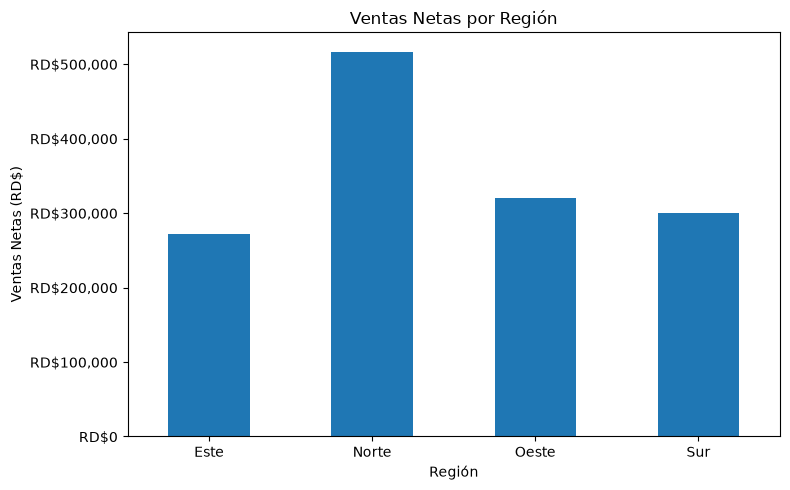

In [36]:
# GRÁFICO 1: VENTAS NETAS POR REGIÓN

ventas_region = df.groupby("region")["venta_neta"].sum()

plt.figure(figsize=(8, 5))

ventas_region.plot(kind="bar")

plt.title("Ventas Netas por Región")
plt.xlabel("Región")
plt.ylabel("Ventas Netas (RD$)")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"RD${x:,.0f}")
)

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("grafico_ventas_region.png", dpi=300, bbox_inches="tight")

plt.show()

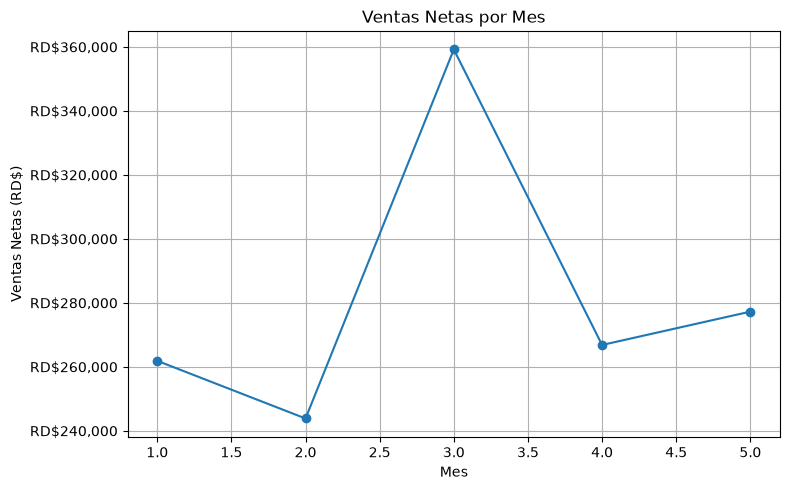

In [37]:
# GRÁFICO 2: VENTAS NETAS POR MES

ventas_mes = df.groupby("mes")["venta_neta"].sum()

plt.figure(figsize=(8, 5))

plt.plot(
    ventas_mes.index,
    ventas_mes.values,
    marker="o"
)

plt.title("Ventas Netas por Mes")
plt.xlabel("Mes")
plt.ylabel("Ventas Netas (RD$)")

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"RD${x:,.0f}")
)

plt.grid(True)
plt.tight_layout()

plt.savefig("grafico_ventas_mes.png", dpi=300, bbox_inches="tight")

plt.show()

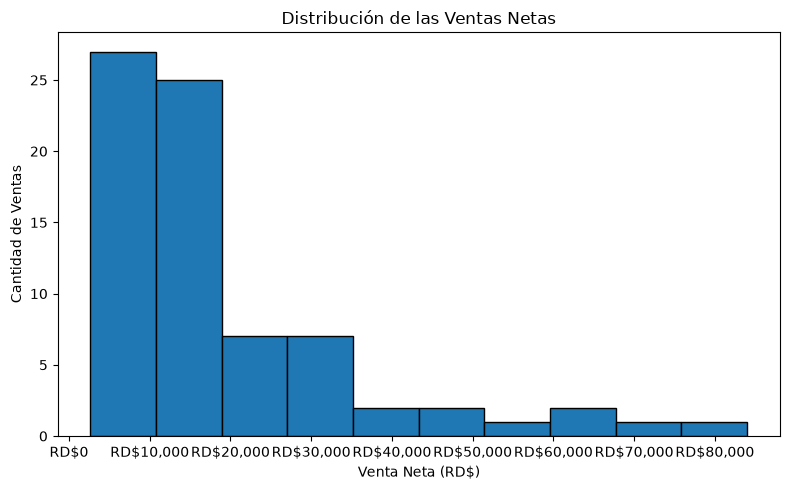

In [38]:
# GRÁFICO 3: DISTRIBUCIÓN DE LAS VENTAS NETAS

plt.figure(figsize=(8, 5))

plt.hist(
    df["venta_neta"],
    bins=10,
    edgecolor="black"
)

plt.title("Distribución de las Ventas Netas")
plt.xlabel("Venta Neta (RD$)")
plt.ylabel("Cantidad de Ventas")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"RD${x:,.0f}")
)

plt.tight_layout()

plt.savefig("grafico_histograma_ventas.png", dpi=300, bbox_inches="tight")

plt.show()

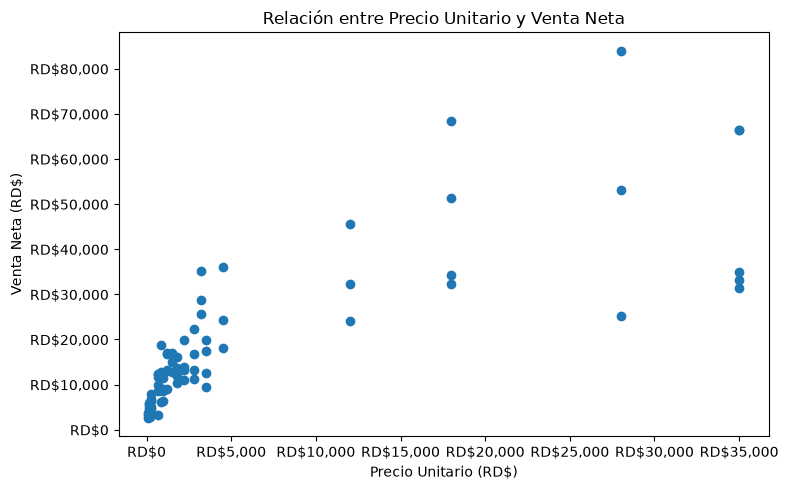

In [39]:
# GRÁFICO 4: RELACIÓN ENTRE PRECIO Y VENTA NETA

plt.figure(figsize=(8, 5))

plt.scatter(
    df["precio_unitario"],
    df["venta_neta"]
)

plt.title("Relación entre Precio Unitario y Venta Neta")
plt.xlabel("Precio Unitario (RD$)")
plt.ylabel("Venta Neta (RD$)")

plt.gca().xaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"RD${x:,.0f}")
)

plt.gca().yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, p: f"RD${x:,.0f}")
)

plt.tight_layout()

plt.savefig("grafico_precio_venta.png", dpi=300, bbox_inches="tight")

plt.show()


In [40]:
# GUARDAR DATASET FINAL LIMPIO

df.to_csv(
    "dataset_limpio_final.csv",
    index=False
)

print("Dataset limpio guardado correctamente.")

Dataset limpio guardado correctamente.
